In [1]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap

In [2]:
measurments = [
    "subhaloId", "distGC", "distBH", "SFR", 
    "DensityMean_v", "DensityDisp_v", "DensityMean_m", "DensityDisp_m",
    "LogDensityDisp_v", "LogDensityDisp_m",
    "VelocityMean_v", "VeloctiyDisp_v", "VelocityMean_m", "VelocityDisp_m",
    "Mach_v", "Mach_m", "SoundspeedMean_v", "SoundspeedMean_m",
    "PressureMean_v", "PressureDisp_v", "PressureMean_m", "PressureDisp_m",
    "LogPressureDisp_m", "LogPressureDisp_v",
    "MagneticFieldMean_m", "MagneticFieldMean_v", 
    "MagneticPressMean_v", "MagneticPressMean_m", "betaMean_v", "betaMean_m",
    "TemperatureMean_v", "MeanElectronAbundance_v", "MeanMolecularWeightMean_v",
    "TemperatureMean_m", "MeanElectronAbundance_m", "MeanMolecularWeightMean_m"
]

In [4]:
def mean(vals, weights):
    if len(vals.shape) == 1:
        return np.sum(vals*weights)/np.sum(weights)
    else:
        return np.sum(vals*weights[:, None], axis=0)/np.sum(weights)


def variance(vals, weights):
    return np.sqrt(mean(vals**2, weights) - mean(vals, weights)**2)


def rms(vals, weights):
    return np.sqrt(np.sum(np.sum(vals**2, axis=-1)*weights)/np.sum(weights))


def cutout_measurments(velocities, density, internal_energy, masses, magneticfield, electronabundance):
    vols = masses/density
    soundspeed = np.sqrt(5/3 * (5/3 - 1) * internal_energy)
    pressure = (5/3 - 1)*density*internal_energy
    molecular_weight = 4/(1 + 3*0.76 + 4*0.76*electronabundance) * (1.6726e-24)
    temperature = (5/3 - 1) * internal_energy/(1.3807e-16) * (10e10) * molecular_weight 

    # density stuff
    dens_mean_v = mean(density, vols)
    dens_mean_m = mean(density, masses)

    s_v = np.log10(density/dens_mean_v)
    s_m = np.log10(density/dens_mean_m)
    
    # machnumber stuff
    vel_bulk_v = mean(velocities, vols)
    vel_rms_v = rms(velocities - vel_bulk_v, vols)
    vel_bulk_m = mean(velocities, masses)
    vel_rms_m = rms(velocities - vel_bulk_m, masses)

    # pressure stuff
    press_mean_v = mean(pressure, vols)
    press_mean_m = mean(pressure, masses)
    ps_v = np.log10(pressure/press_mean_v)
    ps_m = np.log10(pressure/press_mean_m)

    # magentic stuff
    press_mag_v = mean(np.sum(magneticfield**2, axis=-1), vols)/(8*np.pi)
    press_mag_m = mean(np.sum(magneticfield**2, axis=-1), masses)/(8*np.pi)

    return [
        0, 0.0, 0.0, 0.0,
        dens_mean_v, variance(density, vols), dens_mean_m, variance(density, masses),
        variance(s_v, vols), variance(s_m, masses),
        np.linalg.norm(vel_bulk_v), vel_rms_v, np.linalg.norm(vel_bulk_m), vel_rms_m,
        rms((velocities - vel_bulk_v)/soundspeed[:, np.newaxis], vols), rms((velocities - vel_bulk_m)/soundspeed[:, np.newaxis], masses), mean(soundspeed, vols), mean(soundspeed, masses),
        press_mean_v, variance(pressure, vols), press_mean_m, variance(pressure, masses),
        variance(ps_v, vols), variance(ps_m, masses),
        np.linalg.norm(mean(magneticfield, vols)), np.linalg.norm(mean(magneticfield, masses)),
        press_mag_v, press_mag_m, press_mean_v/press_mag_v, press_mean_m/press_mag_m,
        mean(temperature, vols), mean(electronabundance, vols), mean(molecular_weight, vols),
        mean(temperature, masses), mean(electronabundance, masses), mean(molecular_weight, masses)
    ]

In [47]:
def galaxy_scan(smoothing=3, boxes=20):
    table = {key: np.zeros(boxes**3, dtype=np.float64) for key in measurments}

    for i in tqdm(range(len(nicegalaxy.galaxies)), desc="Looping over Galaxies"):
        galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[i])
        box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

        min_corner = galaxy.gas["Coordinates"].min(axis=0)
        max_corner = galaxy.gas["Coordinates"].max(axis=0)
        cutout_size = box_length/2**smoothing

        spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)
        for i, j, k in tqdm(np.ndindex(boxes, boxes, boxes), total=boxes**3, desc="Processing cutouts"):
            cutout_min = min_corner + np.array([i, j, k]) * spacing
            cutout_max = cutout_min + cutout_size
            in_box = (
                (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
                (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
                (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
            )
            center = 0.5 * (cutout_max + cutout_min)
            closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
            gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
            measurment = cutout_measurments(galaxy.gas["Velocities"][in_box], galaxy.gas["Density"][in_box], galaxy.gas["InternalEnergy"][in_box],
                                            galaxy.gas["Masses"][in_box], galaxy.gas["MagneticField"][in_box], galaxy.gas["ElectronAbundance"][in_box])
            measurment[0] = nicegalaxy.galaxies[i]
            measurment[1] = gc_dist
            measurment[2] = closest_bh_dist
            measurment[3] = np.sum(galaxy.gas["StarFormationRate"][in_box])

            cutout_idx = i * boxes**2 + j * boxes + k
            for mes_idx, name in enumerate(measurments):
                table[name][cutout_idx] = measurment[mes_idx]
        break
    return table

In [ ]:
table_coarse = galaxy_scan(smoothing=3, boxes=20)
table_fine = galaxy_scan(smoothing=4, boxes=40)

Looping over Galaxies:   0%|          | 0/198 [00:05<?, ?it/s]


In [3]:
table_coarse_raw = dict()
table_fine_raw = dict()

with h5py.File("data/cgm60kpc.h5", "r") as f:
    for key in f:
        table_coarse_raw[key] = np.array(f[key])

with h5py.File("data/cgm30kpc.h5", "r") as f:
    for key in f:
        table_fine_raw[key] = np.array(f[key])

In [4]:
table_coarse = dict()
table_fine = dict()

for key in table_coarse_raw:
    table_coarse[key] = table_coarse_raw[key][table_coarse_raw["distGC"] < 1000]

for key in table_fine_raw:
    table_fine[key] = table_fine_raw[key][table_fine_raw["distGC"] < 1000]

(array([ 10636.,  42468.,  74272., 151528., 215156., 342288., 328536.,
        237576.,  92280.,  19660.]),
 array([ 18.91251169,  60.96087445, 103.00923721, 145.05759997,
        187.10596273, 229.15432549, 271.20268825, 313.25105101,
        355.29941377, 397.34777653, 439.39613929]),
 <BarContainer object of 10 artists>)

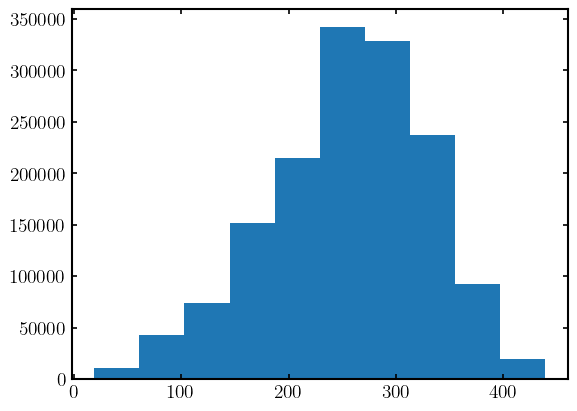

In [223]:
plt.hist(table_fine["distGC"])

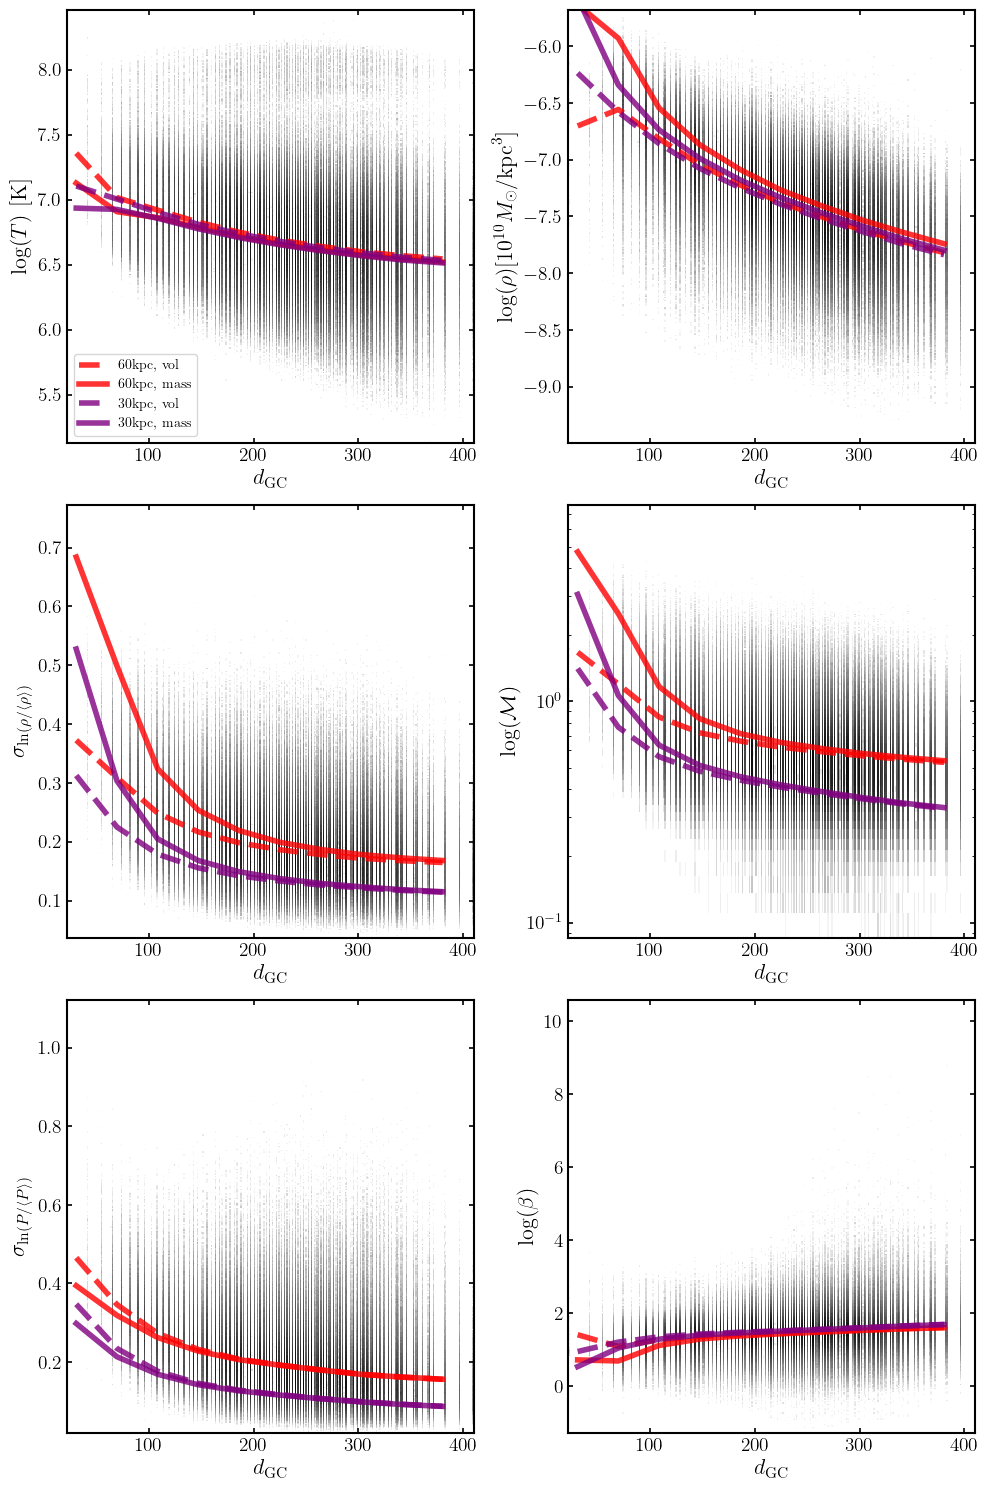

In [270]:
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

ax = axs[0, 0]
value = "TemperatureMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_v"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(T)$ [K]")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.legend(loc="lower left")


ax = axs[0, 1]
value = "DensityMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_v"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(\rho)[10^{10}M_\odot/\mathrm{kpc}^3]$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")

ax = axs[1, 0]
value = "LogDensityDisp"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_m"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_m"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\sigma_{\ln(\rho/\langle\rho\rangle)}$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")

ax = axs[1, 1]
value = "Mach"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_m"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_m"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(\mathcal{M})$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.set_yscale("log")


ax = axs[2, 0]
value = "LogPressureDisp"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_m"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_m"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\sigma_{\ln(P/\langle P \rangle)}$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")

ax = axs[2, 1]
value = "betaMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_v"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(\beta)$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
fig.tight_layout()
fig.savefig("cgm_props.png")

In [ ]:
idx

array([10, 10, 10, ..., 10, 10, 10], shape=(1510255,))

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


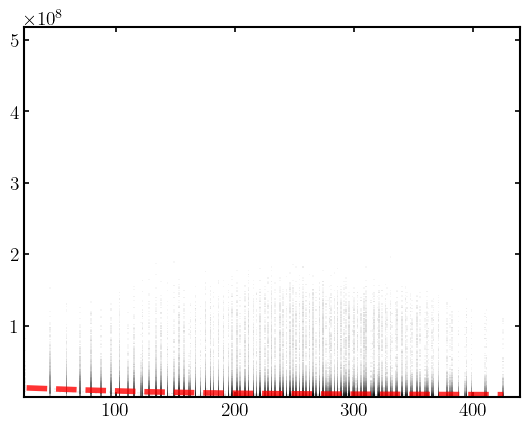

In [234]:
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine["TemperatureMean_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 500, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
plt.plot(bins-delta/2,running_median,'r--',lw=4,alpha=.8)
# plt.yscale("log")

/tmp/ipykernel_52822/1097579664.py:68: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


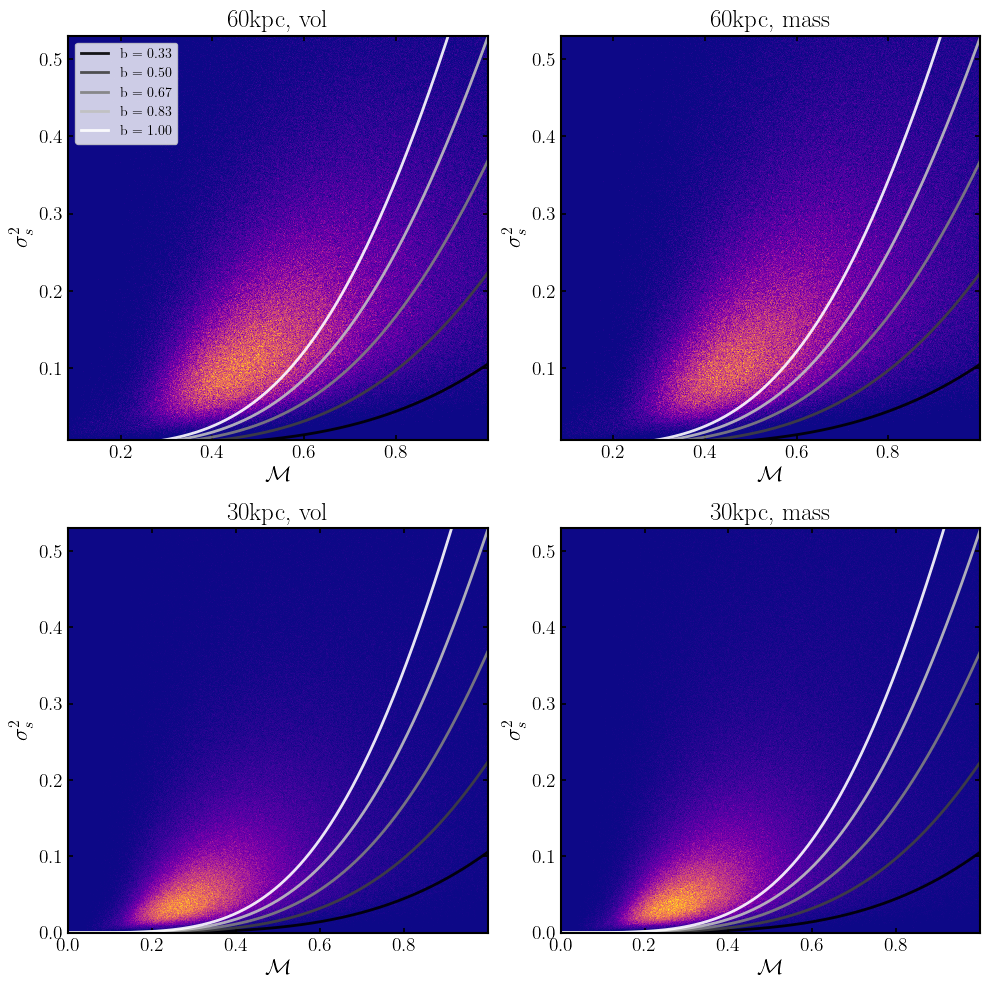

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

ax = axs[0, 0]
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogDensityDisp_v"]**2 < 0.1)]
Y = table_coarse["LogDensityDisp_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogDensityDisp_v"]**2 < 0.1)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.legend()
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, vol")

ax = axs[0, 1]
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogDensityDisp_m"]**2 < 0.1)]
Y = table_coarse["LogDensityDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogDensityDisp_m"]**2 < 0.1)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, mass")


ax = axs[1, 0]
X = table_fine["Mach_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 1) & (table_fine["LogDensityDisp_v"]**2 < 0.1)]
Y = table_fine["LogDensityDisp_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 1) & (table_fine["LogDensityDisp_v"]**2 < 0.1)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, vol")

ax = axs[1, 1]
X = table_fine["Mach_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 1) & (table_fine["LogDensityDisp_m"]**2 < 0.1)]
Y = table_fine["LogDensityDisp_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 1) & (table_fine["LogDensityDisp_m"]**2 < 0.1)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, mass")
fig.tight_layout()
fig.savefig("cutouts-densmach.png")

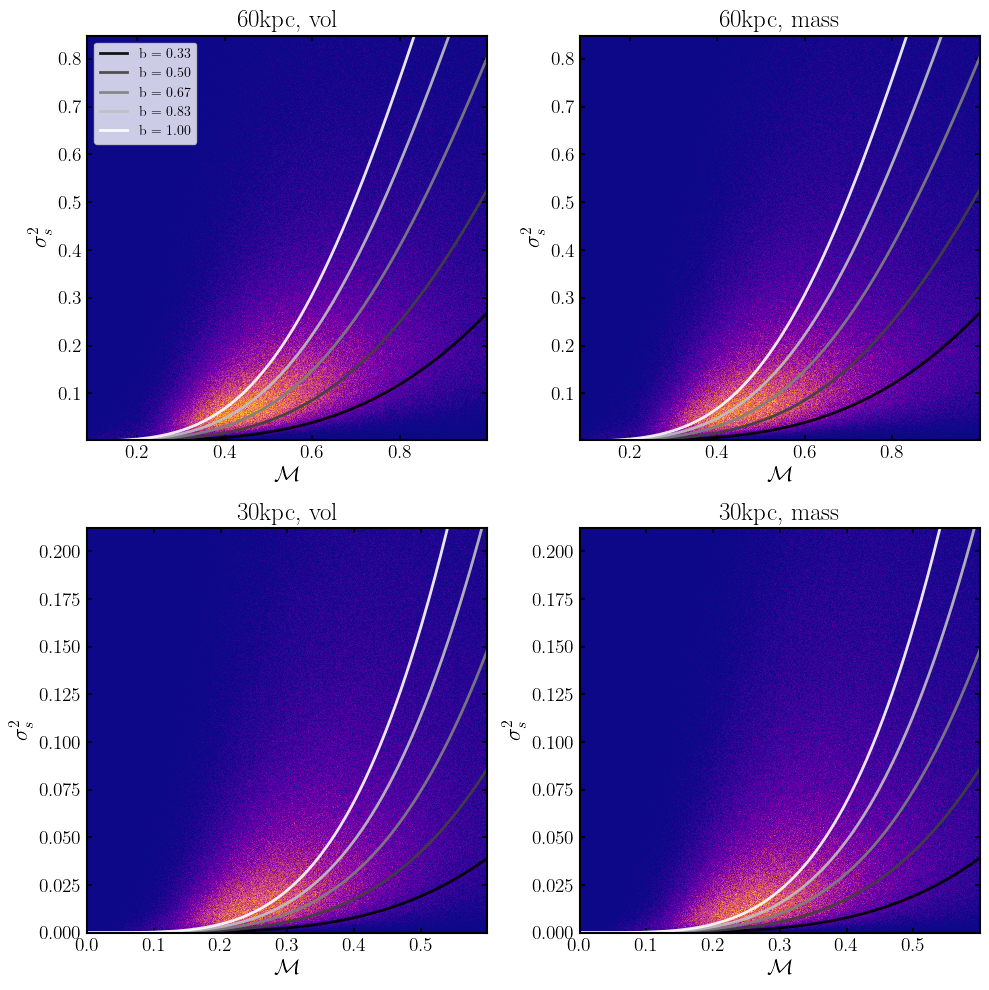

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

ax = axs[0, 0]
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.legend()
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, vol")

ax = axs[0, 1]
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]
Y = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, mass")


ax = axs[1, 0]
X = table_fine["Mach_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]
Y = table_fine["LogPressureDisp_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, vol")

ax = axs[1, 1]
X = table_fine["Mach_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]
Y = table_fine["LogPressureDisp_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, mass")
fig.tight_layout()
fig.savefig("cutouts-pressmach.png")

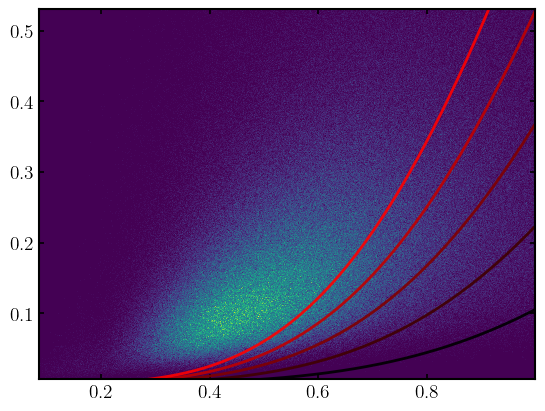

In [170]:
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogDensityDisp_m"]**2 < 0.1)]
Y = table_coarse["LogDensityDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogDensityDisp_m"]**2 < 0.1)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=500)
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])
for i, b in enumerate(b_vals):
    plt.plot(machs, np.log(1 + b**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
plt.show()

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


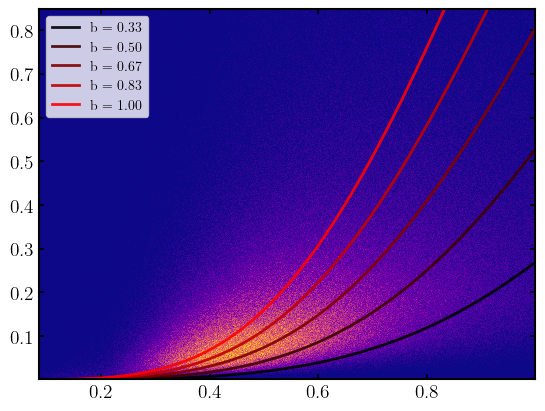

In [27]:
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])
for i, b in enumerate(b_vals):
    plt.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
plt.legend()
plt.show()

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


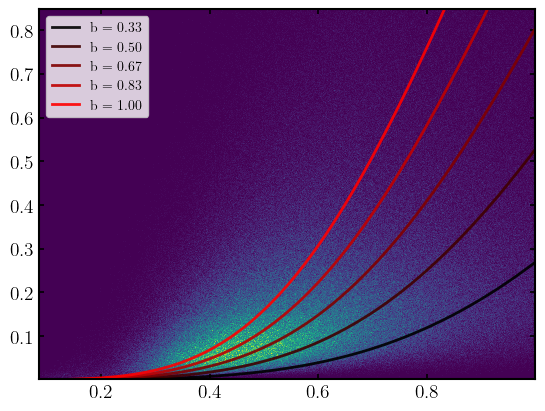

In [171]:
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]
Y = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=500)
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_red", ["black", "red"])
for i, b in enumerate(b_vals):
    plt.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
plt.legend()
plt.show()

/tmp/ipykernel_52822/3338737074.py:16: RuntimeWarning: invalid value encountered in divide
  b3 = np.sqrt(np.exp(Y3) - 1)/((5/3) * X3**2)
/tmp/ipykernel_52822/3338737074.py:17: RuntimeWarning: invalid value encountered in divide
  b4 = np.sqrt(np.exp(Y4) - 1)/((5/3) * X4**2)


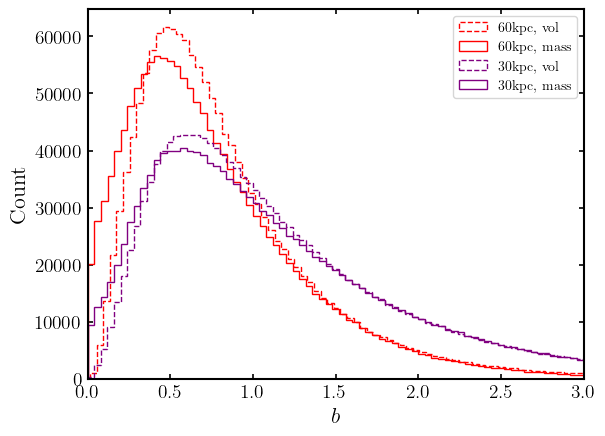

In [39]:
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2

X2 = table_coarse["Mach_m"][(table_coarse["SFR"] == 0)]
Y2 = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2

X3 = table_fine["Mach_v"][(table_fine["SFR"] == 0)]
Y3 = table_fine["LogPressureDisp_v"][(table_fine["SFR"] == 0)]**2 * np.log(10)**2

X4 = table_fine["Mach_m"][(table_fine["SFR"] == 0)]
Y4 = table_fine["LogPressureDisp_m"][(table_fine["SFR"] == 0)]**2 * np.log(10)**2


b = np.sqrt(np.exp(Y) - 1)/(5/3 * X**2)
b2 = np.sqrt(np.exp(Y2) - 1)/((5/3) * X2**2)
b3 = np.sqrt(np.exp(Y3) - 1)/((5/3) * X3**2)
b4 = np.sqrt(np.exp(Y4) - 1)/((5/3) * X4**2)


b = b[b < 4]
b2 = b2[b2 < 4]
b3 = b3[b3 < 4]
b4 = b4[b4 < 4]
plt.hist(b, bins=100, histtype="step", linestyle="--", color="red", label="60kpc, vol")
plt.hist(b2, bins=100, histtype="step", color="red", label="60kpc, mass")
plt.hist(b3, bins=100, histtype="step", color="purple", linestyle="--", label="30kpc, vol")
plt.hist(b4, bins=100, histtype="step", color="purple", label="30kpc, mass")
plt.legend()
plt.xlim(0, 3)
plt.xlabel(r"$b$")
plt.ylabel("Count")
plt.savefig("compressive-ratios.pdf")

/tmp/ipykernel_52822/3950191105.py:16: RuntimeWarning: invalid value encountered in divide
  b3 = np.sqrt(np.exp(Y3) - 1)/((5/3) * X3**2)
/tmp/ipykernel_52822/3950191105.py:17: RuntimeWarning: invalid value encountered in divide
  b4 = np.sqrt(np.exp(Y4) - 1)/((5/3) * X4**2)


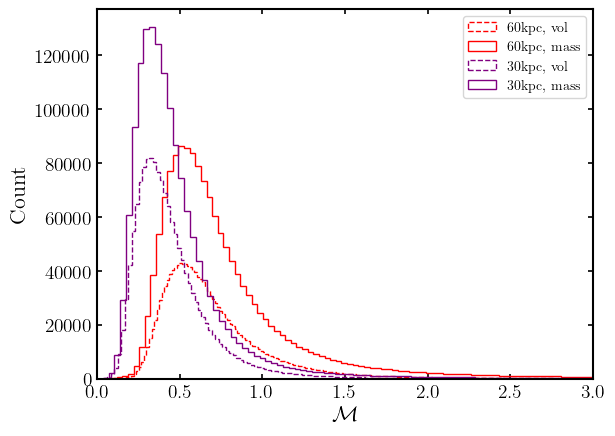

In [42]:
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2

X2 = table_coarse["Mach_m"][(table_coarse["SFR"] == 0)]
Y2 = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2

X3 = table_fine["Mach_v"][(table_fine["SFR"] == 0)]
Y3 = table_fine["LogPressureDisp_v"][(table_fine["SFR"] == 0)]**2 * np.log(10)**2

X4 = table_fine["Mach_m"][(table_fine["SFR"] == 0)]
Y4 = table_fine["LogPressureDisp_m"][(table_fine["SFR"] == 0)]**2 * np.log(10)**2


b = np.sqrt(np.exp(Y) - 1)/(5/3 * X**2)
b2 = np.sqrt(np.exp(Y2) - 1)/((5/3) * X2**2)
b3 = np.sqrt(np.exp(Y3) - 1)/((5/3) * X3**2)
b4 = np.sqrt(np.exp(Y4) - 1)/((5/3) * X4**2)


b = b[b < 4]
b2 = b2[b2 < 4]
b3 = b3[b3 < 4]
b4 = b4[b4 < 4]
plt.hist(X, bins=500, histtype="step", linestyle="--", color="red", label="60kpc, vol")
plt.hist(X2, bins=500, histtype="step", color="red", label="60kpc, mass")
plt.hist(X3, bins=500, histtype="step", color="purple", linestyle="--", label="30kpc, vol")
plt.hist(X4, bins=500, histtype="step", color="purple", label="30kpc, mass")
plt.legend()
plt.xlim(0, 3)
plt.xlabel(r"$\mathcal{M}$")
plt.ylabel("Count")
plt.savefig("machnumbers.pdf")

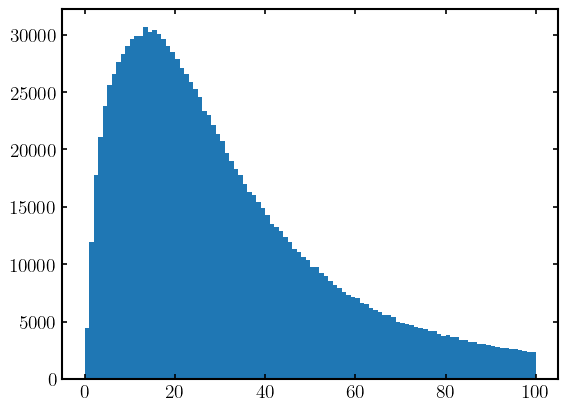

In [143]:
plt.hist(table_coarse["betaMean_v"][(table_coarse["SFR"] == 0) & (table_coarse["betaMean_v"] < 100)], bins=100)
plt.show()

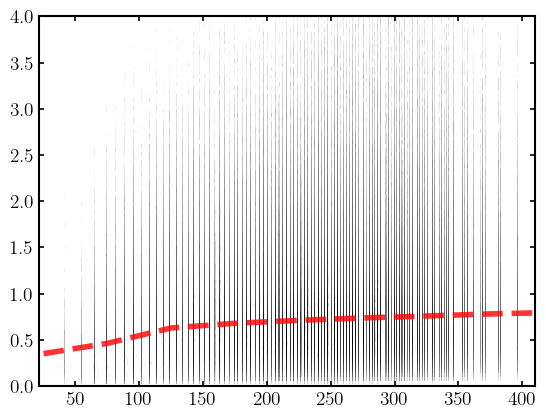

In [ ]:
X2 = table_coarse["Mach_v"][(table_coarse["SFR"] == 0)]
Y2 = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2

b2 = np.sqrt(np.exp(Y2) - 1)/((5/3) * X2**2)
X = table_coarse["distGC"][(table_coarse["SFR"] == 0)]
Y = b2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=500, cmap="Greys", norm="log")
total_bins = 10
bins = np.linspace(50, 500, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
plt.plot(bins-delta/2,running_median,'r--',lw=4,alpha=.8)
plt.ylim(0, 4)
plt.show()

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


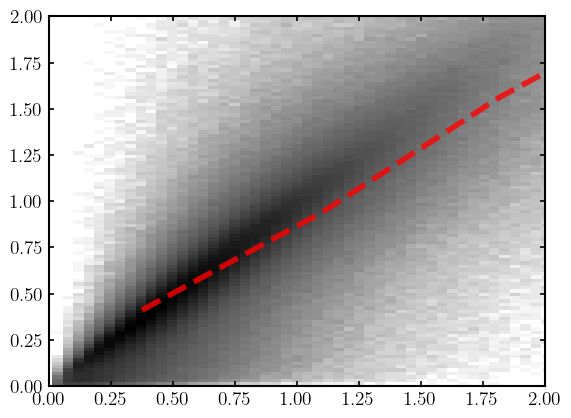

In [181]:
#X = table_coarse["TemperatureMean_v"][(table_coarse["SFR"] == 0)]
# Y = table_coarse["TemperatureMean_m"][(table_coarse["SFR"] == 0)]
X2 = table_coarse["Mach_v"][(table_coarse["SFR"] == 0)]
Y2 = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2
b2 = np.sqrt(np.exp(Y2) - 1)/((5/3) * X2**2)

X2_m = table_coarse["Mach_m"][(table_coarse["SFR"] == 0)]
Y2_m = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0)]**2 * np.log(10)**2
b2_m = np.sqrt(np.exp(Y2_m) - 1)/((5/3) * X2_m**2)

X = b2
Y = b2_m
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
plt.hist2d(X, Y, bins=500, cmap="Greys", norm="log")
total_bins = 30
bins = np.linspace(X.min(), X.max(), total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
plt.plot(bins-delta/2,running_median,'r--',lw=4,alpha=.8)
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()